# ProShares Replication

## HBS Case

### *ProShares Hedge Replication ETF*

$$
\newcommand{\hfri}{\text{hfri}}
\newcommand{\merr}{\text{merr}}
$$

***

# 1. READING - The ProShares ETF Product

### 1. Alternative ETFs

Describe the two types of investments referenced by this term.


Alternative ETFs provide exposure to either (1) alternative asset classes, which invest in nontraditional assets or (2) alternative investment strategies, which employ techniques such as leverage, short selling and derivatives to generate returns.

### 2. Hedge Funds.

**a. Using just the information in the case, what are two measures by which hedge funds are an attractive investment?**

Hedge funds appear attractive based on their higher (1) Sharpe ratios and (2) lower maximum drawdowns. Historically, the HFRI generated nearly comparable returns to the S&P 500 with substantially lower volatility, resulting in superior risk-adjusted performance. Hedge funds also experienced smaller losses during market downturns, providing downside protection.



**b. What are the main benefits of investing in hedge funds via an ETF instead of directly?**

Traditional hedge funds can be difficult to invest in because they often require large minimum investments, restrict withdrawals, charge high fees and disclose relatively little information. 

The ETF offer greater liquidity, transparency, accessibility and diversification at substantially lower fees. However, they primarily capture hedge fund beta rather than the alpha generated by skilled managers.


### 3. The Benchmarks

**a. Explain as simply as possible how HFRI, MLFM, MLFM-ES, and HDG differ in their construction and purpose.**

* HFRI (Hedge Fund Research Index): A benchmark representing the actual performance of a broad universe of hedge funds, constructed as an equally weighted composite of over 2,000 hedge funds.

* MLFM (Merrill Lynch Factor Model): A statistical model designed to replicate HFRI returns using six market factors. It uses a rolling 24-month regression to estimate factor weights, which are updated monthly.

* MLFM-ES (Merrill Lynch Factor Model – Exchange Series): A modified version of MLFM that replaces certain factors with tradable instruments, making the strategy investable while maintaining similar risk-return characteristics.

* HDG (ProShares Hedge Replication ETF): An actual exchange-traded fund that seeks to track MLFM-ES by investing in liquid securities and derivatives, providing investors with accessible, lower-cost exposure to hedge fund-like returns.

In summary: HFRI measures actual hedge fund performance, MLFM statistically replicates that performance, MLFM-ES makes the replication strategy tradable, and HDG implements it as an investable ETF.

**b. How well does the Merrill Lynch Factor Model (MLFM) track the HFRI?**

MLFM tracked the HFRI relatively well, achieving approximately 90% historical correlation. However, the model did not perfectly replicate hedge fund returns, with meaningful performance differences in certain periods. Therefore, the correlation suggests strong directional tracking but does not guarantee small tracking errors.

**c. In which factor does the MLFM have the largest loading? (See a slide in Exhibit 1.)**

The largest loading is the three-month Treasury bill factor (66.5%).
Intuitively, this indicates a substantial allocation to short-term, low-risk instruments. The remaining exposures help create the desired hedge fund-like risk profile.

**d. What are the main concerns you have for how the MLFM attempts to replicate the HFRI?**

The main concerns are the model's limited factor set, backward-looking 24-month regression, inability to capture complex nonlinear exposures and failure to replicate manager-specific alpha. These limitations may produce tracking errors, particularly when hedge fund strategies or market conditions change.

### 4. The HDG Product

**a. What does ProShares ETF, HDG, attempt to track? Is the tracking error small?**
HDG seeks to track MLFM-ES, a tradable index designed to replicate the risk-return characteristics of HFRI. MLFM-ES exhibited a 99.7% correlation with MLFM, suggesting very close historical tracking. 

However, this does not establish that HDG itself has negligible tracking error, particularly relative to the ultimate HFRI benchmark.

**b. HDG is, by construction, delivering beta for investors. Isn't the point of hedge funds to generate alpha? Then why would HDG be valuable?**
HDG can be valuable even without generating alpha because hedge fund beta may provide diversification benefits and improve portfolio risk-adjusted returns. By offering relatively low-cost exposure to hedge fund-like systematic risks, HDG may reduce portfolio volatility and improve the Sharpe ratio without requiring investors to identify skilled hedge fund managers.

**c. The fees of a typical hedge-fund are 2% on total assets plus 20% of excess returns if positive. HDG's expense ratio is roughly 1% on total assets. What would their respective net Sharpe Ratios be, assuming both have a gross excess returns of 10% and volatility of 20%?**
The traditional hedge fund's net Sharpe ratio is 0.32, compared with HDG's 0.45. Assuming identical gross returns and volatility, HDG delivers superior net risk-adjusted performance because of its substantially lower fee structure.

***

# 2.  Analyzing the Data

Use the data in `proshares_analysis_data.xlsx`. 

It has monthly data on financial indexes and ETFs from `Aug 2011` through `May 2025`.

In [17]:
#run this everytime an edit is made in utils.py so that we can use the helper functions in this Python Notebook
import importlib
import utils2
importlib.reload(utils2)

import numpy as np
import pandas as pd

pd.options.display.float_format = "{:.4f}".format
path = "proshares_analysis_data.xlsx"

## 1. 

For the series in the "hedge fund series" tab, report the following summary statistics:
* mean
* volatility
* Sharpe ratio

Annualize these statistics.

In [3]:
hedge_fund_returns = pd.read_excel(path, sheet_name = "hedge_fund_series", index_col = 0)

summary_stats = pd.DataFrame({"Mean": hedge_fund_returns.mean() * 12,
                              "Volatility": hedge_fund_returns.std() * np.sqrt(12),
                              "Sharpe": (hedge_fund_returns.mean() / hedge_fund_returns.std()) * np.sqrt(12)})

display(summary_stats)


,Mean,Volatility,Sharpe
HFRIFWI Index,0.0513,0.0588,0.8722
MLEIFCTR Index,0.0385,0.0552,0.6976
MLEIFCTX Index,0.0365,0.0551,0.6629
HDG US Equity,0.0269,0.0574,0.4684
QAI US Equity,0.0288,0.0498,0.5783


## 2.

For the series in the "hedge fund series" tab, calculate the following statistics related to tail-risk.
* Skewness
* Excess Kurtosis (in excess of 3)
* VaR (.05) - the fifth quantile of historic returns
* CVaR (.05) - the mean of the returns at or below the fifth quantile
* Maximum drawdown - include the dates of the max/min/recovery within the max drawdown period.

There is no need to annualize any of these statistics.

In [18]:
tail_stats = pd.DataFrame({"Skewness": hedge_fund_returns.skew(),
                           "Excess Kurtosis": hedge_fund_returns.kurt(),
                           "VaR (0.05)": hedge_fund_returns.quantile(0.05),
                           "CVaR (0.05)": hedge_fund_returns.apply(lambda x: x[x <= x.quantile(0.05)].mean())})

drawdown_stats = hedge_fund_returns.apply(utils2.max_drawdown_stats).T

tail_stats = tail_stats.join(drawdown_stats)

display(tail_stats)

,Skewness,Excess Kurtosis,VaR (0.05),CVaR (0.05),Max Drawdown,Peak Date,Trough Date,Recovery Date
HFRIFWI Index,-0.9483,5.6574,-0.0240,-0.0360,-0.1155,2019-12-31 00:00:00,2020-03-31 00:00:00,2020-08-31 00:00:00
MLEIFCTR Index,-0.2900,1.6309,-0.0270,-0.0350,-0.1243,2021-06-30 00:00:00,2022-09-30 00:00:00,2024-02-29 00:00:00
MLEIFCTX Index,-0.2735,1.5898,-0.0270,-0.0349,-0.1244,2021-06-30 00:00:00,2022-09-30 00:00:00,2024-02-29 00:00:00
HDG US Equity,-0.2749,1.7765,-0.0299,-0.0368,-0.1407,2021-06-30 00:00:00,2022-09-30 00:00:00,2024-07-31 00:00:00
QAI US Equity,-0.4335,1.4492,-0.0172,-0.0310,-0.1377,2021-06-30 00:00:00,2022-09-30 00:00:00,2024-02-29 00:00:00


## 3. 

For the series in the "hedge fund series" tab, run a regression of each against SPY (found in the "merrill factors" tab.) Include an intercept. Report the following regression-based statistics:
* Market Beta
* Treynor Ratio
* Information ratio

Annualize these three statistics as appropriate.

In [19]:
import statsmodels.api as sm

merrill_factors = pd.read_excel(path, sheet_name = "merrill_factors", index_col = 0, parse_dates = True)
spy = merrill_factors["SPY US Equity"]
rf = merrill_factors["USGG3M Index"]

regression_results = hedge_fund_returns.apply(lambda x: utils2.regression_stats(x, spy, rf = rf, periods = 12)).T

display(regression_results[["Market Beta", "Treynor Ratio", "Information Ratio"]])

,Market Beta,Treynor Ratio,Information Ratio
HFRIFWI Index,0.3463,0.1049,0.0553
MLEIFCTR Index,0.3425,0.0685,-0.4364
MLEIFCTX Index,0.3415,0.0628,-0.5105
HDG US Equity,0.3506,0.0336,-0.8624
QAI US Equity,0.3014,0.0455,-0.5978


## 4. 

Discuss the previous statistics, and what they tell us about...

* **the differences between SPY and the hedge-fund series?** 
The hedge fund series exhibit substantially lower market betas than SPY, with betas ranging from approximately 0.30 to 0.35 compared to SPY's beta of 1. This suggests that hedge funds and their replication strategies have lower sensitivity to broad equity market movements, potentially providing diversification benefits. However, lower market beta does not necessarily imply lower total risk, so volatility and tail-risk measures are also important when comparing their performance.


* **which performs better between HDG and QAI.** 
Based on the regression statistics, QAI outperforms HDG on a risk-adjusted basis. QAI has a lower market beta (0.3014 versus 0.3506), a higher Treynor ratio (0.0455 versus 0.0336), and a less negative information ratio (−0.5978 versus −0.8624). These results suggest that QAI delivers greater excess returns per unit of market risk and better regression-adjusted performance, although the remaining risk and return statistics should also be considered.


* **whether HDG and the ML series capture the most notable properties of HFRI.** 
HDG and the Merrill Lynch series appear successful in replicating HFRI's market exposure, with all three exhibiting betas close to HFRI's 0.3463. However, they are less successful in replicating HFRI's risk-adjusted performance. HFRI has a substantially higher Treynor ratio (0.1049) than MLFM (0.0685), MLFM-ES (0.0628), and HDG (0.0336). Additionally, the replication strategies exhibit negative information ratios compared to HFRI's slightly positive ratio. Overall, the replication strategies capture HFRI's systematic equity exposure but do not fully reproduce its risk-adjusted returns.

## 5. 

Report the correlation matrix for these assets.
* Show the correlations as a heat map.
* Which series have the highest and lowest correlations?

,HFRIFWI Index,MLEIFCTR Index,MLEIFCTX Index,HDG US Equity,QAI US Equity
HFRIFWI Index,1.0000,0.9005,0.8999,0.8900,0.8578
MLEIFCTR Index,0.9005,1.0000,0.9999,0.9879,0.8936
MLEIFCTX Index,0.8999,0.9999,1.0000,0.9877,0.8934
HDG US Equity,0.8900,0.9879,0.9877,1.0000,0.8793
QAI US Equity,0.8578,0.8936,0.8934,0.8793,1.0000


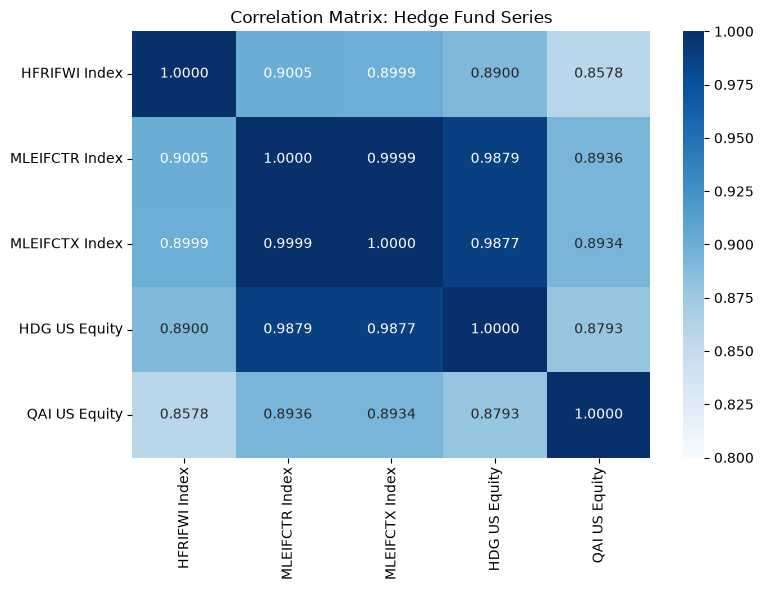

Highest Correlation:
('MLEIFCTR Index', 'MLEIFCTX Index') 0.999887161754553

Lowest Correlation:
('HFRIFWI Index', 'QAI US Equity') 0.8577856261449315


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = hedge_fund_returns.corr()
display(corr_matrix)

plt.figure(figsize = (8, 6))
sns.heatmap(corr_matrix, annot = True, fmt = ".4f", cmap = "Blues", vmin = 0.8, vmax = 1)
plt.title("Correlation Matrix: Hedge Fund Series")
plt.tight_layout()
plt.show()

corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k = 1).astype(bool)).stack()

print("Highest Correlation:")
print(corr_pairs.idxmax(), corr_pairs.max())

print("\nLowest Correlation:")
print(corr_pairs.idxmin(), corr_pairs.min())

## 6.

Replicate HFRI with the six factors listed on the "merrill factors" tab. Include a constant, and run the unrestricted regression,

$$\begin{align}
r^{\hfri}_{t} &= \alpha^{\merr} + x_{t}^{\merr}\beta^{\merr} + \epsilon_{t}^{\merr}\\[5pt]
\hat{r}^{\hfri}_{t} &= \hat{\alpha}^{\merr} + x_{t}^{\merr}\hat{\beta}^{\merr}
\end{align}$$

Note that the second equation is just our notation for the fitted replication.

In [7]:
#align HFRI and the six factors by date
regression_data = pd.concat([hedge_fund_returns["HFRIFWI Index"], merrill_factors], axis = 1).dropna()

y = regression_data["HFRIFWI Index"]
X = sm.add_constant(regression_data[merrill_factors.columns])

#run unrestricted OLS regression
model = sm.OLS(y, X).fit()

display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          HFRIFWI Index   R-squared:                       0.843
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     144.6
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           2.10e-62
Time:                        15:03:13   Log-Likelihood:                 605.85
No. Observations:                 169   AIC:                            -1198.
Df Residuals:                     162   BIC:                            -1176.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0011      0.001      1.631      0.105      -0.000       0.003
SPY US Equity     0.0435      0.032      1.365      0.174      -0.019       0.106
USGG3M Index      0.3249      0.338      0.963      0.337      -0.342       0.992
EEM US Equity     0.0856      0.019      4.461      0.000       0.048       0.123
EFA US Equity     0.0740      0.031      2.380      0.018       0.013       0.135
EUO US Equity     0.0296      0.016      1.865      0.064      -0.002       0.061
IWM US Equity     0.1458      0.019      7.615      0.000       0.108       0.184
==============================================================================
Omnibus:                       26.269   Durbin-Watson:                   1.878
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               96.203
Skew:                          -0.476   Prob(JB):                     1.29e-21
Kurtosis:                       6.571   Cond. No.                         640.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**a. Report the intercept and betas.**

In [8]:
coefficients = model.params.to_frame("Coefficient")

display(coefficients)

,Coefficient
const,0.0011
SPY US Equity,0.0435
USGG3M Index,0.3249
EEM US Equity,0.0856
EFA US Equity,0.0740
EUO US Equity,0.0296
IWM US Equity,0.1458


The unrestricted regression produces a monthly intercept of 0.0011 (0.11%), with factor betas of 0.0435 for SPY, 0.3249 for USGG3M, 0.0856 for EEM, 0.0740 for EFA, 0.0296 for EUO, and 0.1458 for IWM. The largest factor loading is on the three-month Treasury rate factor (USGG3M), followed by the Russell 2000 ETF (IWM). The positive intercept suggests that HFRI earns a small positive average monthly return beyond what is explained by the six factors.

**b. Are the betas realistic position sizes, or do they require huge long-short positions?**

The unrestricted regression produces a monthly intercept of 0.0011 (0.11%), with factor betas of 0.0435 for SPY, 0.3249 for USGG3M, 0.0856 for EEM, 0.0740 for EFA, 0.0296 for EUO, and 0.1458 for IWM. The largest factor loading is on the three-month Treasury rate factor (USGG3M), followed by the Russell 2000 ETF (IWM). The positive intercept suggests that HFRI earns a small positive average monthly return beyond what is explained by the six factors.

**c. Report the R-squared.**

In [9]:
print(f"R-squared: {model.rsquared:.4f}")

R-squared: 0.8427


This R-squared value of 0.8427 indicates a reasonably strong in-sample fit, although it does not guarantee good out-of-sample replication.

d. Report the volatility of $\epsilon^{\merr}$, the tracking error.

In [10]:
tracking_error = model.resid.std() * np.sqrt(12)

print(f"Annualized Tracking Error: {tracking_error:.4f}")

Annualized Tracking Error: 0.0233


This suggests the fitted model tracks HFRI reasonably closely in sample, although the replication still has unexplained return variation.

## 7.

Let's examine the replication out-of-sample (OOS).

Starting with $t = 61$ month of the sample, do the following:

* Use the previous 60 months of data to estimate the regression equation. 
This gives time-t estimates of the regression parameters, $\tilde{\alpha}^{\merr}_{t}$ and $\tilde{\beta}^{\merr}_{t}$.

* Use the estimated regression parameters, along with the time-t regressor values, $x^{\merr}_{t}$, calculate the time-t replication value that is, with respect to the regression estimate, built "out-of-sample" (OOS).

$$\hat{r}^{\hfri}_{t} \equiv \tilde{\alpha}^{\merr} + (x_{t}^{\merr})'\tilde{\beta}^{\merr}$$

* Step forward to $t = 62$, and now use $t = 2$ through $t = 61$ for the estimation. Re-run the steps above, and continue this process throughout the data series. Thus, we are running a rolling, 60-month regression for each point-in-time.

In [12]:
WINDOW = 60
oos_predictions = []

for t in range(WINDOW, len(regression_data)):
    #previous 60 months for estimation
    train = regression_data.iloc[t - WINDOW:t]

    y_train = train["HFRIFWI Index"]
    X_train = sm.add_constant(train[merrill_factors.columns], has_constant = "add")

    #estimate regression
    rolling_model = sm.OLS(y_train, X_train).fit()

    #current month's factor returns
    X_test = sm.add_constant(regression_data.iloc[[t]][merrill_factors.columns], has_constant = "add")

    #out-of-sample replication
    prediction = rolling_model.predict(X_test).iloc[0]

    oos_predictions.append(prediction)

oos_results = pd.DataFrame({"HFRI": regression_data["HFRIFWI Index"].iloc[WINDOW:],
                            "OOS Replication": oos_predictions})
display(oos_results.head())


,HFRI,OOS Replication
2016-08-31,0.0043,0.0050
2016-09-30,0.0065,0.0050
2016-10-31,-0.0059,-0.0044
2016-11-30,0.0077,0.0117
2016-12-31,0.0101,0.0077


How well does the out-of-sample replication perform with respect to the target?

OOS Correlation: 0.9013
OOS Tracking Error: 0.0275


,Annualized Mean,Annualized Volatility
HFRI,0.0641,0.0633
OOS Replication,0.0479,0.0594


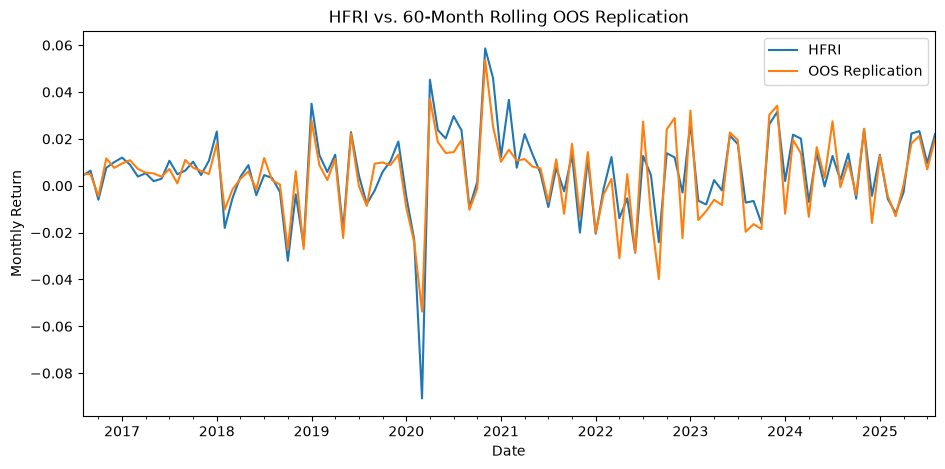

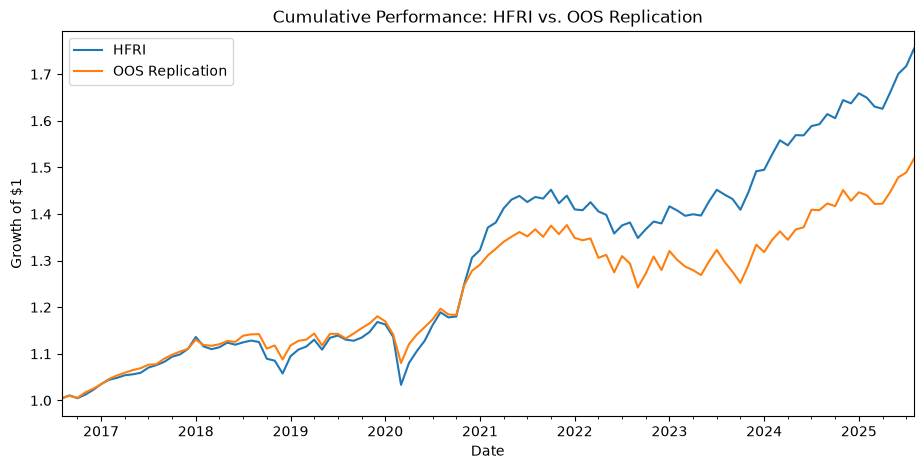

In [14]:
oos_summary = pd.DataFrame({"Annualized Mean": oos_results.mean() * 12,
                            "Annualized Volatility": oos_results.std() * np.sqrt(12)})

oos_correlation = oos_results.corr().iloc[0, 1]

oos_tracking_error = (oos_results["HFRI"] - oos_results["OOS Replication"]).std() * np.sqrt(12)

print(f"OOS Correlation: {oos_correlation:.4f}")
print(f"OOS Tracking Error: {oos_tracking_error:.4f}")

display(oos_summary)

ax = oos_results.plot(figsize = (11, 5), title = "HFRI vs. 60-Month Rolling OOS Replication")
ax.set_xlabel("Date")
ax.set_ylabel("Monthly Return")
plt.show()

cumulative_returns = (1 + oos_results).cumprod()
ax = cumulative_returns.plot(figsize = (11, 5), title = "Cumulative Performance: HFRI vs. OOS Replication")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
plt.show()


The 60-month rolling out-of-sample regression provides a reasonably strong replication of HFRI, with a correlation of 0.9013 and an annualized tracking error of approximately 2.75%. As illustrated by the monthly return comparison, the replication captures much of HFRI's month-to-month movements, although deviations remain. The replication also captures HFRI's volatility relatively well, with annualized volatility of 5.94% compared to HFRI's 6.33%.

However, the replication falls short in terms of average returns, generating an annualized mean of 4.79% compared to HFRI's 6.41%. The cumulative performance graph can help illustrate how these return differences compound over time.

Overall, the six-factor model successfully captures much of HFRI's systematic return variation and volatility, but does not fully replicate its average returns. This suggests that while hedge fund beta can be approximated using market factors, some components of HFRI's performance remain unexplained by the model.

***

# 3. EXTRA - Other Estimations

### 1.

In `Section 2`, we estimated the replications using an intercept. Try the full-sample estimation, but this time without an intercept.

$$\begin{align}
r^{\hfri}_{t} &= \alpha^{merr} + x_{t}^{\merr}\beta^{\merr} + \epsilon_{t}^{\merr}\\[5pt]
\check{r}^{\hfri}_{t} &= \check{\alpha}^{\merr} + x_{t}^{\merr}\check{\beta}^{\merr}
\end{align}$$

Report

* the regression beta. How does it compare to the estimated beta with an intercept, $\hat{\beta}^{\merr}$?

* the mean of the fitted value, $\check{r}^{\hfri}_{t}$. How does it compare to the mean of the HFRI?

* the correlations of the fitted values, $\check{r}^{\hfri}_{t}$ to the HFRI. How does the correlation compare to that of the fitted values with an intercept, $\hat{r}^{\hfri}_{t}$

Do you think Merrill and ProShares fit their replicators with an intercept or not?

### 2.

Merrill constrains the weights of each asset in its replication regression of HFRI. Try constraining your weights by re-doing 2.6.

* Use Non-Negative Least Squares (NNLS) instead of OLS.
* Go further by using a Generalized Linear Model to put separate interval constraints on each beta, rather than simply constraining them to be non-negative.

#### Hints
* Try using LinearRegression in scikit-learn with the parameter `positive=True`. 
* Try using GLM in statsmodels.

# 4. EXTRA - Other Decompositions

### 1. 

Let's decompose a few other targets to see if they behave as their name suggests.

* Regress HEFA on the same style factors used to decompose HFRI. Does HEFA appear to be a currency-hedged version of EFA?

* Decompose TRVCI with the same style factors used to decompose HFRI. The TRVCI Index tracks venture capital funds--in terms of our styles, what best describes venture capital?

* TAIL is an ETF that tracks SPY, but that also buys put options to protect against market downturns. Calculate the statistics in questions 2.1-2.3 for TAIL. Does it seem to behave as indicated by this description? That is, does it have high correlation to SPY while delivering lower tail risk?

### 2. 

The ProShares case introduces Levered ETFs. ProShares made much of its name originally through levered, or "geared" ETFs.

Explain conceptually why Levered ETFs may track their index well for a given day but diverge over time. How is this exacerbated in volatile periods like 2008?

### 3.

Analyze SPXU and UPRO relative to SPY.
- SPXU is ProShares -3x SPX ETF.
- UPRO is ProShres +3x SPX ETF.

Questions:
* Analyze them with the statistics from 2.1-2.3. 

* Do these two ETFs seem to live up to their names?

* Plot the cumulative returns of both these ETFs along with SPY.

* What do you conclude about levered ETFs?

***